# Упражнение 7.2. n-шаговый TD против суммы TD-ошибок

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 7 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch07.pdf).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
SIZE = 5
TERMINALS = {(0, 0), (4, 4)}
ACTIONS = [(1, 0), (0, 1), (-1, 0), (0, -1)]
GAMMA = 1.0
ALPHA = 0.1
V_INIT = 5.0

NS = [1, 2, 4, 8, 16]
NUM_EPISODES = 500
NUM_RUNS = 100

In [3]:
def step(state, action):
    r, c = state
    dr, dc = action
    new_r = max(0, min(SIZE - 1, r + dr))
    new_c = max(0, min(SIZE - 1, c + dc))
    next_state = (new_r, new_c)
    reward = -1.0
    done = next_state in TERMINALS
    return next_state, reward, done

NON_TERMINALS = [(r, c) for r in range(SIZE) for c in range(SIZE) if (r, c) not in TERMINALS]

def random_start(rng):
    return NON_TERMINALS[rng.integers(len(NON_TERMINALS))]

def random_action(rng):
    return ACTIONS[rng.integers(len(ACTIONS))]

In [4]:
def compute_true_V(tol=1e-9):
    V = np.zeros((SIZE, SIZE))
    while True:
        new_V = V.copy()
        delta = 0.0
        for r in range(SIZE):
            for c in range(SIZE):
                if (r, c) in TERMINALS:
                    continue
                v = 0.0
                for a in ACTIONS:
                    ns, reward, _ = step((r, c), a)
                    v += 0.25 * (reward + GAMMA * V[ns])
                new_V[r, c] = v
                delta = max(delta, abs(v - V[r, c]))
        V = new_V
        if delta < tol:
            return V

V_TRUE = compute_true_V()
print("Истинные V(s):")
print(np.round(V_TRUE, 2))

Истинные V(s):
[[  0.   -23.   -34.33 -39.67 -41.67]
 [-23.   -30.67 -36.33 -39.   -39.67]
 [-34.33 -36.33 -37.33 -36.33 -34.33]
 [-39.67 -39.   -36.33 -30.67 -23.  ]
 [-41.67 -39.67 -34.33 -23.     0.  ]]


In [5]:
MASK = np.array([[(r, c) not in TERMINALS for c in range(SIZE)] for r in range(SIZE)])

def rmse(V):
    return float(np.sqrt(((V[MASK] - V_TRUE[MASK]) ** 2).mean()))

In [6]:
def n_step_td_classic(n, num_episodes, seed):
    rng = np.random.default_rng(seed)
    V = np.full((SIZE, SIZE), V_INIT)
    for s in TERMINALS:
        V[s] = 0.0
    history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        S = [None] * (n + 1)
        R = [0.0] * (n + 1)
        S[0] = random_start(rng)
        T = float("inf")
        t = 0
        while True:
            if t < T:
                a = random_action(rng)
                ns, r, done = step(S[t % (n + 1)], a)
                S[(t + 1) % (n + 1)] = ns
                R[(t + 1) % (n + 1)] = r
                if done:
                    T = t + 1
            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += GAMMA ** (i - tau - 1) * R[i % (n + 1)]
                if tau + n < T:
                    G += GAMMA ** n * V[S[(tau + n) % (n + 1)]]
                s_tau = S[tau % (n + 1)]
                if s_tau not in TERMINALS:
                    V[s_tau] += ALPHA * (G - V[s_tau])
            if tau == T - 1:
                break
            t += 1
        history[ep] = rmse(V)
    return history

In [7]:
def n_step_td_sum_errors(n, num_episodes, seed):
    rng = np.random.default_rng(seed)
    V = np.full((SIZE, SIZE), V_INIT)
    for s in TERMINALS:
        V[s] = 0.0
    history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        states = [random_start(rng)]
        deltas = []
        done = False
        while not done:
            s = states[-1]
            a = random_action(rng)
            ns, r, done = step(s, a)
            v_ns = 0.0 if done else V[ns]
            deltas.append(r + GAMMA * v_ns - V[s])
            states.append(ns)
            tau = len(deltas) - n
            if tau >= 0:
                s_tau = states[tau]
                if s_tau not in TERMINALS:
                    G_sum = 0.0
                    for i in range(n):
                        G_sum += GAMMA ** i * deltas[tau + i]
                    V[s_tau] += ALPHA * G_sum
        T = len(deltas)
        for tau in range(max(0, T - n + 1), T):
            s_tau = states[tau]
            if s_tau in TERMINALS:
                continue
            G_sum = 0.0
            for i in range(T - tau):
                G_sum += GAMMA ** i * deltas[tau + i]
            V[s_tau] += ALPHA * G_sum
        history[ep] = rmse(V)
    return history

In [8]:
rmse_classic = np.zeros((len(NS), NUM_EPISODES))
rmse_sum_err = np.zeros((len(NS), NUM_EPISODES))

for i, n in enumerate(NS):
    for run in tqdm(range(NUM_RUNS), desc=f"n={n}"):
        rmse_classic[i] += n_step_td_classic(n, NUM_EPISODES, seed=run)
        rmse_sum_err[i] += n_step_td_sum_errors(n, NUM_EPISODES, seed=run)

rmse_classic /= NUM_RUNS
rmse_sum_err /= NUM_RUNS

n=1:   0%|          | 0/100 [00:00<?, ?it/s]

n=2:   0%|          | 0/100 [00:00<?, ?it/s]

n=4:   0%|          | 0/100 [00:00<?, ?it/s]

n=8:   0%|          | 0/100 [00:00<?, ?it/s]

n=16:   0%|          | 0/100 [00:00<?, ?it/s]

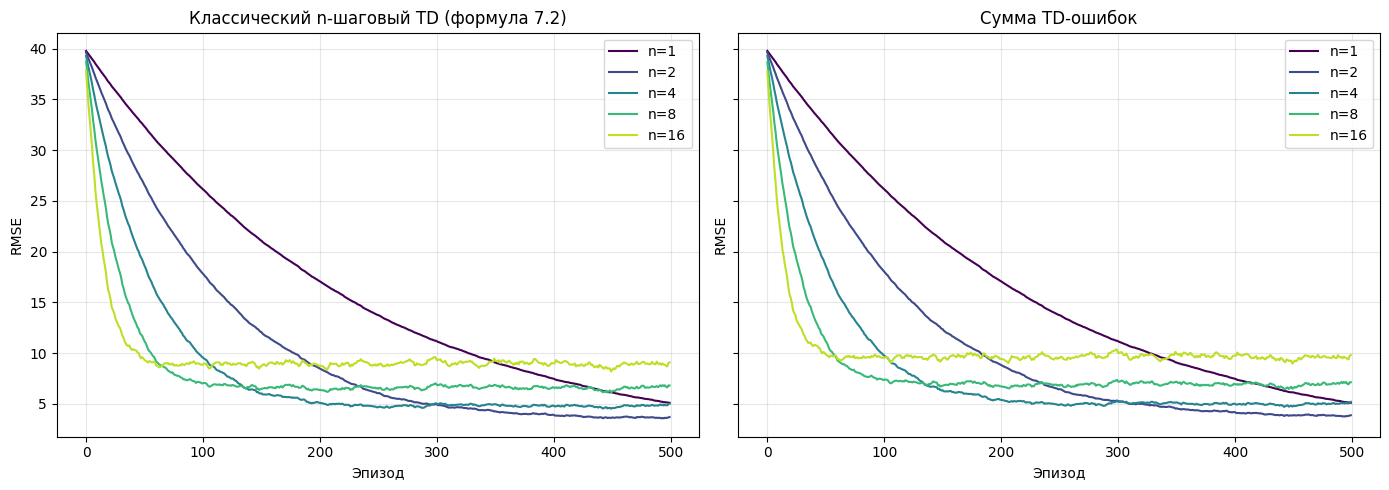

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(NS)))

for i, n in enumerate(NS):
    axes[0].plot(rmse_classic[i], label=f"n={n}", color=colors[i])
    axes[1].plot(rmse_sum_err[i], label=f"n={n}", color=colors[i])

axes[0].set_title("Классический n-шаговый TD (формула 7.2)")
axes[1].set_title("Сумма TD-ошибок")
for ax in axes:
    ax.set_xlabel("Эпизод")
    ax.set_ylabel("RMSE")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

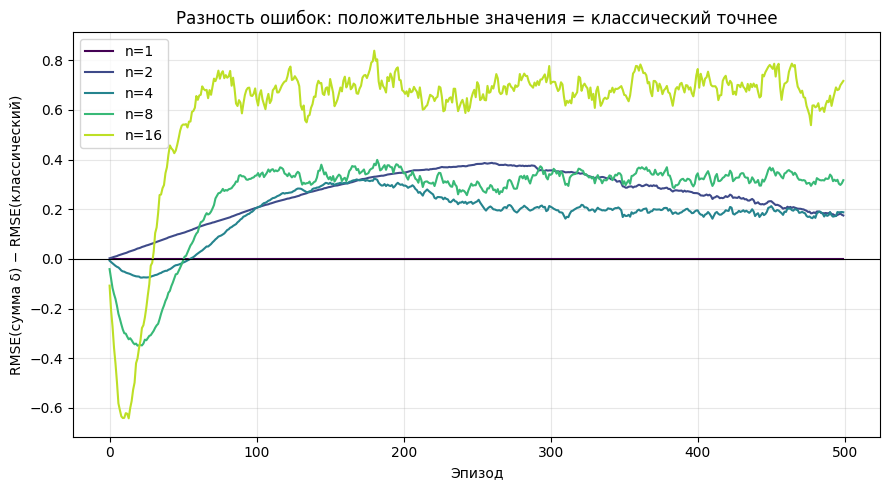

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, n in enumerate(NS):
    ax.plot(rmse_sum_err[i] - rmse_classic[i], label=f"n={n}", color=colors[i])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Эпизод")
ax.set_ylabel("RMSE(сумма δ) − RMSE(классический)")
ax.set_title("Разность ошибок: положительные значения = классический точнее")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()